In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json


def plot_citation_distribution(br_publications):
    # Preprocess the data
    def is_international(authorships_str):
        try:
            authorships = json.loads(authorships_str.replace("'", '"'))
            for author in authorships:
                if "countries" in author and author["countries"]:
                    if any(country != "BR" for country in author["countries"]):
                        return True
            return False
        except:
            return False

    # Classify publications
    br_publications["is_international"] = br_publications["authorships"].apply(
        is_international
    )

    # Prepare data for plotting
    domestic = br_publications[~br_publications["is_international"]]
    international = br_publications[br_publications["is_international"]]

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True, sharex=True)

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)

    # Plot domestic publications
    sns.scatterplot(
        x=domestic["cited_by_count"].value_counts().index,
        y=domestic["cited_by_count"].value_counts().values,
        ax=axes[0],
        color="blue",
        alpha=0.7,
    )
    axes[0].set_title("Domestic Collaborations")
    axes[0].set_xlabel("Citation Count")
    axes[0].set_ylabel("Number of Publications")
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")

    # Plot international publications
    sns.scatterplot(
        x=international["cited_by_count"].value_counts().index,
        y=international["cited_by_count"].value_counts().values,
        ax=axes[1],
        color="orange",
        alpha=0.7,
    )
    axes[1].set_title("International Collaborations")
    axes[1].set_xlabel("Citation Count")
    axes[1].set_ylabel("")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")

    plt.tight_layout()
    return fig

In [ ]:
def plot_subfield_collaboration(br_publications, authors):
    # Preprocess publication data
    def get_subfield_collaboration(authorships_str):
        try:
            # Extract author IDs from publication metadata
            author_list = json.loads(authorships_str.replace("'", '"'))
            author_ids = [a['id'] for a in author_list]
            
            # Get subfields from authors dataframe
            subfields = authors[authors['id'].isin(author_ids)]['primary_subfield'].unique()
            
            return 'Multi-Subfield' if len(subfields) > 1 else 'Single-Subfield'
        except:
            return 'Unknown'

    # Classify publications
    br_publications['collab_type'] = br_publications['authorships'].apply(get_subfield_collaboration)
    filtered = br_publications[br_publications['collab_type'] != 'Unknown']
    
    # Split data
    single = filtered[filtered['collab_type'] == 'Single-Subfield']
    multi = filtered[filtered['collab_type'] == 'Multi-Subfield']
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True, sharex=True)
    
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)
    
    # Plot single-subfield
    sns.scatterplot(
        x=single['cited_by_count'].value_counts().index,
        y=single['cited_by_count'].value_counts().values,
        ax=axes[0],
        color='green',
        alpha=0.7
    )
    axes[0].set_title('Single-Subfield Collaborations')
    axes[0].set_xlabel('Citation Count (log scale)')
    axes[0].set_ylabel('Number of Publications')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    
    # Plot multi-subfield
    sns.scatterplot(
        x=multi['cited_by_count'].value_counts().index,
        y=multi['cited_by_count'].value_counts().values,
        ax=axes[1],
        color='purple',
        alpha=0.7
    )
    axes[1].set_title('Multi-Subfield Collaborations')
    axes[1].set_xlabel('Citation Count (log scale)')
    axes[1].set_ylabel('')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    
    plt.tight_layout()
    return fig

In [3]:
br_publications_df = pd.read_csv("../../data/raw/publication_meta/br_publication_meta.csv")

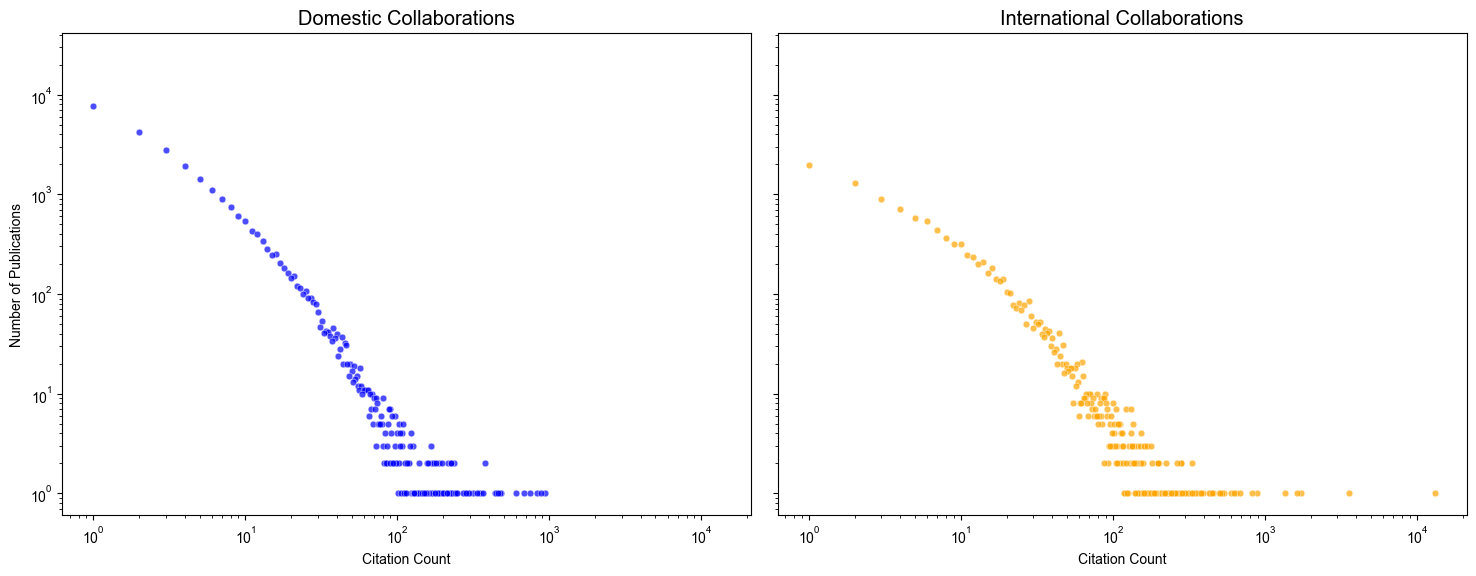

In [4]:
plot_citation_distribution(br_publications_df)
plt.show()

In [5]:
authors_df = pd.read_csv("../../data/processed/6_authors.csv")

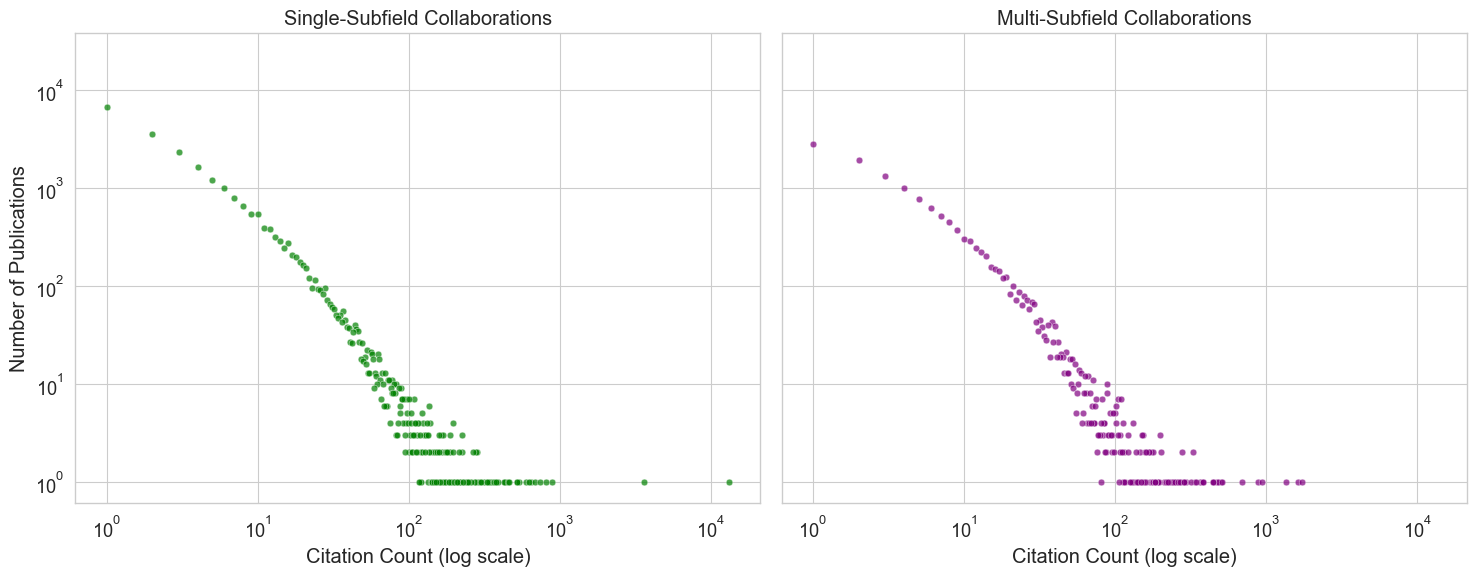

In [6]:
plot_subfield_collaboration(br_publications_df, authors_df)
plt.show()